In [ ]:
#imports
import torch.nn as nn
import random
import torch # Main PyTorch Library
import torchvision # Pytorch library for image analysis
from torchvision import transforms  # Transform function used to modify and preprocess all the images
from torch import nn # Used for creating the layers and loss function
from torch.optim import Adam # Adam Optimizer
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects
from sklearn.preprocessing import LabelEncoder # Label Encoder to encode the classes from strings to numbers
import matplotlib.pyplot as plt # Used for visualizing the images and plotting the training progress
from PIL import Image # Used to read the images from the directory
import pandas as pd # Used to read/create dataframes (csv) and process tabular data
import numpy as np # preprocessing and numerical/mathematical operations
import os # Used to read the images path from the directory
from torch.utils.data import random_split #Used to split data sets
import torch.nn.functional as F
import math
device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
print("Device available: ", device)

Device available:  cuda


In [ ]:
import torchvision.transforms as transforms

# Normalize all images: shift pixel values within -1 and 1
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

full_train_dataset = torchvision.datasets.CIFAR10(
    root="./data",                  # save/load dataset in this folder
    train=True,                     # use training data
    download=True,                  # download if needed
    transform=transform             # apply transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",                  # save/load dataset in this folder
    train=False,                    # use test data
    download=True,                  # download if needed
    transform=transform             # apply transform
)

# print size of each data sets
print("Train size:", len(full_train_dataset))
print("Test size:", len(test_dataset))


100%|██████████| 170M/170M [00:05<00:00, 28.9MB/s]


Train size: 50000
Test size: 10000


In [ ]:
# split full training data set to training and validation parts
train_size = int(0.8 * len(full_train_dataset))   # 80% for training
val_size = len(full_train_dataset) - train_size   # 20% for validation

train_dataset, val_dataset = random_split(
    full_train_dataset,             # dataset to split
    [train_size, val_size],         # sizes of split parts
    generator=torch.Generator().manual_seed(42)   # makes the train/validation split stay the same every time
)

# printing each data sets sizes
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))


Train size: 40000
Val size: 10000
Test size: 10000


In [ ]:
batch_size = 64


torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
#data loader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)   # shuffled train batches
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)      # validation batches
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)    # test batches


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ProductGStiefelConv2d(nn.Module):
    """
    Convolution layer with:
      - fast inner variables: X, Z   (updated every batch)
      - slow outer geometry: Q1, ell (updated once per epoch or every few epochs)

    Geometry:
        B = Q1 diag(exp(ell)) Q1^T

    Conventions:
      - flattened filter matrix W is interpreted mathematically as shape (n, p)
        where
            n = in_channels * kernel_size * kernel_size
            p = out_channels

      - Stiefel variables are stored in optimizer-friendly shape:
            Q1 parameter shape = (rank, n)
            X  parameter shape = (rank, p)

      - Euclidean variable:
            Z parameter shape = (n-rank, p)
    """

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        diffeo,
        stride: int = 1,
        padding: int = 0,
        bias: bool = True,
        metric_lr_scale: float = 1.0,
    ):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

        self.diffeo = diffeo

        self.n = in_channels * kernel_size * kernel_size
        self.p = out_channels
        self.rank = diffeo.rank

        self.metric_lr_scale = metric_lr_scale

        B0 = diffeo.B.detach().clone()
        device = B0.device
        dtype = B0.dtype

        B0 = 0.5 * (B0 + B0.t())

        evals, evecs = torch.linalg.eigh(B0)

        idx = torch.argsort(evals, descending=True)[:self.rank]
        evals_r = torch.clamp(evals[idx], min=1e-8)
        Q1_0 = evecs[:, idx]  # (n, rank)

        # store Q1 as (rank, n)
        self.Q1 = nn.Parameter(Q1_0.t().contiguous())

        # Lambda = diag(exp(ell))
        self.ell = nn.Parameter(torch.log(evals_r.contiguous()))

        # initialize fast inner coordinates
        X_std, Z_std = diffeo.random_product_point(self.p)

        # store X directly as (rank, p)
        self.X = nn.Parameter(X_std.contiguous())
        self.Z = nn.Parameter(Z_std.contiguous())

        if bias:
            self.bias = nn.Parameter(
                torch.zeros(out_channels, device=device, dtype=dtype)
            )
        else:
            self.register_parameter("bias", None)

        self.update_diffeo_metric_()

    def get_Q1_matrix(self) -> torch.Tensor:
        return self.Q1.t()   # (n, rank)

    def get_Lambda_matrix(self) -> torch.Tensor:
        return torch.diag(torch.exp(self.ell))

    def get_metric_B(self) -> torch.Tensor:
        Q1 = self.get_Q1_matrix()          # (n, rank)
        Lambda = self.get_Lambda_matrix()  # (rank, rank)
        B = Q1 @ Lambda @ Q1.t()
        B = 0.5 * (B + B.t())
        return B

    @torch.no_grad()
    def update_diffeo_metric_(self) -> None:
        B = self.get_metric_B().detach()
        self.diffeo.set_B(B)

    @torch.no_grad()
    def derive_Q2(self) -> torch.Tensor:
        Q1 = self.get_Q1_matrix()

        if self.rank == self.n:
            return torch.empty(self.n, 0, device=Q1.device, dtype=Q1.dtype)

        I = torch.eye(self.n, device=Q1.device, dtype=Q1.dtype)
        M = torch.cat([Q1, I], dim=1)
        Q_full, _ = torch.linalg.qr(M, mode="complete")
        Q2 = Q_full[:, self.rank:self.n]
        return Q2

    @torch.no_grad()
    def refresh_product_coordinates_(self) -> None:
        X_std_old = self.X.contiguous()   # (rank, p)
        Z_std_old = self.Z
        W_np = self.diffeo.phi_inverse(X_std_old, Z_std_old)

        self.update_diffeo_metric_()

        if hasattr(self.diffeo, "phi") and callable(self.diffeo.phi):
            X_std_new, Z_std_new = self.diffeo.phi(W_np)
            self.X.data.copy_(X_std_new.contiguous())
            self.Z.data.copy_(Z_std_new.contiguous())

    def reconstruct_weight(self) -> torch.Tensor:
        X_std = self.X                    # (rank, p)
        Z_std = self.Z                    # (n-rank, p)

        W_flat_np = self.diffeo.phi_inverse(X_std, Z_std)
        W_flat_pn = W_flat_np.t()

        W = W_flat_pn.view(
            self.out_channels,
            self.in_channels,
            self.kernel_size,
            self.kernel_size,
        )
        return W

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        W = self.reconstruct_weight()
        return F.conv2d(
            x,
            W,
            bias=self.bias,
            stride=self.stride,
            padding=self.padding,
        )

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class WRNBasicBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1,
        dropout=0.3,
        conv0_layer=None,
        conv1_layer=None,
    ):
        super().__init__()
        self.equal_in_out = (in_channels == out_channels)
        self.dropout = dropout

        self.bn0 = nn.BatchNorm2d(in_channels)

        self.conv0 = conv0_layer if conv0_layer is not None else nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )

        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv1 = conv1_layer if conv1_layer is not None else nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1, padding=1, bias=False
        )

        self.convdim = None
        if not self.equal_in_out:
            self.convdim = nn.Conv2d(
                in_channels, out_channels,
                kernel_size=1, stride=stride, padding=0, bias=False
            )

        self.reset_parameters()

    def reset_parameters(self):
        if isinstance(self.conv0, nn.Conv2d):
            nn.init.orthogonal_(self.conv0.weight)
        if isinstance(self.conv1, nn.Conv2d):
            nn.init.orthogonal_(self.conv1.weight)
        if self.convdim is not None:
            nn.init.orthogonal_(self.convdim.weight)

        nn.init.ones_(self.bn0.weight)
        nn.init.zeros_(self.bn0.bias)
        nn.init.ones_(self.bn1.weight)
        nn.init.zeros_(self.bn1.bias)

    def forward(self, x):
        o1 = F.relu(self.bn0(x), inplace=True)

        y = self.conv0(o1)
        o2 = F.relu(self.bn1(y), inplace=True)
        o2 = F.dropout(o2, p=self.dropout, training=self.training)
        z = self.conv1(o2)

        shortcut = self.convdim(o1) if self.convdim is not None else x
        return z + shortcut

In [ ]:
class WRNGroup(nn.Module):
    def __init__(
        self,
        num_blocks,
        in_channels,
        out_channels,
        first_stride,
        dropout=0.3,
        block_builder=None,
        group_index=None,
    ):
        super().__init__()
        blocks = []

        for i in range(num_blocks):
            stride = first_stride if i == 0 else 1
            block_in = in_channels if i == 0 else out_channels

            if block_builder is None:
                block = WRNBasicBlock(
                    in_channels=block_in,
                    out_channels=out_channels,
                    stride=stride,
                    dropout=dropout,
                )
            else:
                block = block_builder(
                    group_index=group_index,
                    block_index=i,
                    in_channels=block_in,
                    out_channels=out_channels,
                    stride=stride,
                    dropout=dropout,
                )

            blocks.append(block)

        self.blocks = nn.Sequential(*blocks)

    def forward(self, x):
        return self.blocks(x)

In [ ]:
class WideResNet(nn.Module):
    def __init__(
        self,
        depth=28,
        width=10,
        num_classes=10,
        dropout=0.3,
        stem_layer=None,
        block_builder=None,
    ):
        super().__init__()
        assert (depth - 4) % 6 == 0, "depth should be 6n+4"

        n = (depth - 4) // 6
        widths = [16 * width, 32 * width, 64 * width]

        self.conv0 = stem_layer if stem_layer is not None else nn.Conv2d(
            3, 16, kernel_size=3, stride=1, padding=1, bias=False
        )

        self.group0 = WRNGroup(
            num_blocks=n,
            in_channels=16,
            out_channels=widths[0],
            first_stride=1,
            dropout=dropout,
            block_builder=block_builder,
            group_index=0,
        )
        self.group1 = WRNGroup(
            num_blocks=n,
            in_channels=widths[0],
            out_channels=widths[1],
            first_stride=2,
            dropout=dropout,
            block_builder=block_builder,
            group_index=1,
        )
        self.group2 = WRNGroup(
            num_blocks=n,
            in_channels=widths[1],
            out_channels=widths[2],
            first_stride=2,
            dropout=dropout,
            block_builder=block_builder,
            group_index=2,
        )

        self.bn = nn.BatchNorm2d(widths[2])
        self.fc = nn.Linear(widths[2], num_classes)

        self.reset_parameters()

    def reset_parameters(self):
        if isinstance(self.conv0, nn.Conv2d):
            nn.init.orthogonal_(self.conv0.weight)

        nn.init.ones_(self.bn.weight)
        nn.init.zeros_(self.bn.bias)

        nn.init.normal_(self.fc.weight, mean=0.0, std=2 / (self.fc.in_features ** 0.5))
        nn.init.zeros_(self.fc.bias)

    def constrained_layers(self):
        """
        Return all ProductGStiefelConv2d layers in the network.
        """
        layers = []
        for m in self.modules():
            if isinstance(m, ProductGStiefelConv2d):
                layers.append(m)
        return layers

    @torch.no_grad()
    def update_all_diffeo_metrics_(self):
        """
        Push each layer's current learned metric B into its diffeo object.
        Call before inner updates if outer variables changed.
        """
        for layer in self.constrained_layers():
            layer.update_diffeo_metric_()

    @torch.no_grad()
    def refresh_all_product_coordinates_(self):
        """
        After an outer update of Q1 / ell, rebuild product coordinates
        so X, Z remain consistent with the new metric.
        """
        for layer in self.constrained_layers():
            layer.refresh_product_coordinates_()

    def forward(self, x):
        x = self.conv0(x)
        x = self.group0(x)
        x = self.group1(x)
        x = self.group2(x)
        x = F.relu(self.bn(x), inplace=True)
        x = F.avg_pool2d(x, 8, 1, 0)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [ ]:
#a helper that decides whether a layer should be constrained
def is_feasible_gstiefel_conv(in_channels, out_channels, kernel_size, rank):
    n = in_channels * kernel_size * kernel_size
    p = out_channels
    return (p <= n) and (p <= rank <= n)


Now define a builder for blocks.

Our stem conv0: 3 -> 16 is feasible, so we can constrain it too.

In [ ]:
def make_block_builder(diffeo_factory):
    """
    diffeo_factory(in_channels, out_channels, kernel_size, group_index, block_index, conv_name)
    should return a diffeo object with appropriate B/rank for that layer.
    """

    def build_block(group_index, block_index, in_channels, out_channels, stride, dropout):
        # -----------------------------
        # conv0
        # -----------------------------
        conv0_layer = None
        n0 = in_channels * 3 * 3
        p0 = out_channels

        if p0 <= n0:
            diffeo0 = diffeo_factory(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=3,
                group_index=group_index,
                block_index=block_index,
                conv_name="conv0",
            )

            if is_feasible_gstiefel_conv(in_channels, out_channels, 3, diffeo0.rank):
                conv0_layer = ProductGStiefelConv2d(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=3,
                    diffeo=diffeo0,
                    stride=stride,
                    padding=1,
                    bias=False,
                )

        # -----------------------------
        # conv1
        # -----------------------------
        conv1_layer = None
        n1 = out_channels * 3 * 3
        p1 = out_channels

        if p1 <= n1:
            diffeo1 = diffeo_factory(
                in_channels=out_channels,
                out_channels=out_channels,
                kernel_size=3,
                group_index=group_index,
                block_index=block_index,
                conv_name="conv1",
            )

            if is_feasible_gstiefel_conv(out_channels, out_channels, 3, diffeo1.rank):
                conv1_layer = ProductGStiefelConv2d(
                    in_channels=out_channels,
                    out_channels=out_channels,
                    kernel_size=3,
                    diffeo=diffeo1,
                    stride=1,
                    padding=1,
                    bias=False,
                )

        return WRNBasicBlock(
            in_channels=in_channels,
            out_channels=out_channels,
            stride=stride,
            dropout=dropout,
            conv0_layer=conv0_layer,
            conv1_layer=conv1_layer,
        )

    return build_block

In [ ]:
def make_stem_layer(diffeo_factory):
    diffeo = diffeo_factory(
        in_channels=3,
        out_channels=16,
        kernel_size=3,
        group_index=-1,
        block_index=-1,
        conv_name="stem",
    )

    if is_feasible_gstiefel_conv(3, 16, 3, diffeo.rank):
        return ProductGStiefelConv2d(
            in_channels=3,
            out_channels=16,
            kernel_size=3,
            diffeo=diffeo,
            stride=1,
            padding=1,
            bias=False,
        )
    else:
        print(f"Fallback stem conv: (3->16, k=3, rank={diffeo.rank})")
        return nn.Conv2d(
            3, 16, kernel_size=3, stride=1, padding=1, bias=False
        )

create diagonal B for each layer.

In [ ]:
# import future annotations so type hints can reference the class itself safely
from __future__ import annotations

import torch


def sym(A: torch.Tensor) -> torch.Tensor:
    return 0.5 * (A + A.T)


class GeneralizedStiefelDiffeomorphismTorch:
    def __init__(self, B: torch.Tensor, tol: float = 1e-10):
        self.tol = tol
        self.set_B(B)

    def _factorize_B(self, B: torch.Tensor) -> None:
        self.B = B
        self.device = B.device
        self.dtype = B.dtype

        if B.ndim != 2 or B.shape[0] != B.shape[1]:
            raise ValueError("B must be a square matrix.")

        self.n = B.shape[0]

        Bsym = sym(B)
        evals, Q = torch.linalg.eigh(Bsym)

        idx = torch.argsort(evals, descending=True)
        evals = evals[idx]
        Q = Q[:, idx]

        if torch.any(evals < -self.tol):
            raise ValueError("B must be positive semidefinite.")

        rank = int((evals > self.tol).sum().item())

        self.rank = rank
        self.Q = Q
        self.evals = evals
        self.Q1 = Q[:, :rank]
        self.Q2 = Q[:, rank:]

        if rank > 0:
            lam = evals[:rank]
            self.Lambda = torch.diag(lam)
            self.Lambda_half = torch.diag(torch.sqrt(lam))
            self.Lambda_half_inv = torch.diag(1.0 / torch.sqrt(lam))
        else:
            self.Lambda = torch.empty((0, 0), device=self.device, dtype=self.dtype)
            self.Lambda_half = torch.empty((0, 0), device=self.device, dtype=self.dtype)
            self.Lambda_half_inv = torch.empty((0, 0), device=self.device, dtype=self.dtype)

    def set_B(self, B: torch.Tensor) -> None:
        """
        Replace the metric B and recompute all decomposition quantities.
        Used by train-B after Q1 / ell updates.
        """
        self._factorize_B(B)

    def in_generalized_stiefel(self, W: torch.Tensor) -> bool:
        if W.ndim != 2 or W.shape[0] != self.n:
            return False

        p = W.shape[1]
        gram = W.T @ self.B @ W
        I = torch.eye(p, device=W.device, dtype=W.dtype)
        return torch.norm(gram - I) <= 1e2 * self.tol

    def phi(self, W: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        if W.ndim != 2 or W.shape[0] != self.n:
            raise ValueError(f"W must have shape ({self.n}, p).")

        QtW = self.Q.T @ W
        W1 = QtW[:self.rank, :]
        W2 = QtW[self.rank:, :]

        if self.rank > 0:
            X = self.Lambda_half @ W1
        else:
            X = torch.empty((0, W.shape[1]), device=W.device, dtype=W.dtype)

        Z = W2
        return X, Z

    def phi_inverse(self, X: torch.Tensor, Z: torch.Tensor) -> torch.Tensor:
        if X.ndim != 2:
            raise ValueError("X must be a matrix of shape (rank, p).")
        if Z.ndim != 2:
            raise ValueError("Z must be a matrix of shape (n-rank, p).")
        if X.shape[1] != Z.shape[1]:
            raise ValueError("X and Z must have the same number of columns.")
        if X.shape[0] != self.rank:
            raise ValueError(f"X must have shape ({self.rank}, p).")
        if Z.shape[0] != self.n - self.rank:
            raise ValueError(f"Z must have shape ({self.n - self.rank}, p).")

        if self.rank > 0:
            W1 = self.Lambda_half_inv @ X
        else:
            W1 = torch.empty((0, X.shape[1]), device=X.device, dtype=X.dtype)

        W = self.Q1 @ W1 + self.Q2 @ Z
        return W

    def random_product_point(self, p: int) -> tuple[torch.Tensor, torch.Tensor]:
        if p > self.rank:
            raise ValueError(
                f"Cannot create a Stiefel point with p={p} columns when rank(B)={self.rank}. "
                "You need p <= rank(B)."
            )

        A = torch.randn(self.rank, p, device=self.device, dtype=self.dtype)
        Qx, Rx = torch.linalg.qr(A, mode="reduced")

        d = torch.diagonal(Rx, 0)
        s = torch.sign(d)
        s[s == 0] = 1
        Qx = Qx * s.unsqueeze(0)

        X = Qx
        Z = torch.zeros(self.n - self.rank, p, device=self.device, dtype=self.dtype)
        return X, Z

    def init_from_W(self, W: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        if not self.in_generalized_stiefel(W):
            raise ValueError("Input W does not satisfy W^T B W = I up to tolerance.")
        return self.phi(W)

    def print_summary(self) -> None:
        print(f"n = {self.n}")
        print(f"rank(B) = {self.rank}")
        print("positive eigenvalues =", self.evals[:self.rank])
        print("Q1 shape =", tuple(self.Q1.shape))
        print("Q2 shape =", tuple(self.Q2.shape))

In [ ]:
import math
import torch

dtype = torch.float32

def make_B_for_conv(n, p, device, dtype=torch.float32):
    target_rank = math.ceil(1.1 * p)

    if target_rank > n:
        raise ValueError(
            f"Cannot set rank(B)={target_rank} because n={n} and p={p}."
        )

    zero_count = n - target_rank

    d = torch.linspace(0.1, 2.5, n, device=device, dtype=dtype)
    d[:zero_count] = 0.0
    B = torch.diag(d)

    return B, target_rank


def diffeo_factory(in_channels, out_channels, kernel_size, group_index, block_index, conv_name):
    n = in_channels * kernel_size * kernel_size
    p = out_channels

    if p > n:
        raise ValueError(
            f"Infeasible layer: p={p} > n={n} for {conv_name}, "
            f"group={group_index}, block={block_index}"
        )

    B, target_rank = make_B_for_conv(n, p, device=device, dtype=torch.float32)
    diffeo = GeneralizedStiefelDiffeomorphismTorch(B=B)

    layer_name = (
        "stem" if conv_name == "stem"
        else f"group{group_index}.block{block_index}.{conv_name}"
    )

    if diffeo.rank < p:
        raise ValueError(
            f"rank(B)={diffeo.rank} < p={p} for {layer_name}"
        )

    print(f"{layer_name}: n={n}, p={p}, target_rank={target_rank}, actual_rank={diffeo.rank}")

    return diffeo

In [ ]:
stem_layer = make_stem_layer(diffeo_factory)
block_builder = make_block_builder(diffeo_factory)

stem: n=27, p=16, target_rank=18, actual_rank=18


In [ ]:
model = WideResNet(
    depth=28,
    width=10,
    num_classes=10,
    dropout=0.3,
    stem_layer=stem_layer,
    block_builder=block_builder,
)

group0.block0.conv1: n=1440, p=160, target_rank=176, actual_rank=176
group0.block1.conv0: n=1440, p=160, target_rank=176, actual_rank=176
group0.block1.conv1: n=1440, p=160, target_rank=176, actual_rank=176
group0.block2.conv0: n=1440, p=160, target_rank=176, actual_rank=176
group0.block2.conv1: n=1440, p=160, target_rank=176, actual_rank=176
group0.block3.conv0: n=1440, p=160, target_rank=176, actual_rank=176
group0.block3.conv1: n=1440, p=160, target_rank=176, actual_rank=176
group1.block0.conv0: n=1440, p=320, target_rank=352, actual_rank=352
group1.block0.conv1: n=2880, p=320, target_rank=352, actual_rank=352
group1.block1.conv0: n=2880, p=320, target_rank=352, actual_rank=352
group1.block1.conv1: n=2880, p=320, target_rank=352, actual_rank=352
group1.block2.conv0: n=2880, p=320, target_rank=352, actual_rank=352
group1.block2.conv1: n=2880, p=320, target_rank=352, actual_rank=352
group1.block3.conv0: n=2880, p=320, target_rank=352, actual_rank=352
group1.block3.conv1: n=2880, p=320

In [ ]:
LR_X_STIEFEL = 0.001
LR_Q1_STIEFEL = 0.001
LR_Z_EUCLID = 0.01
LR_ELL_EUCLID = 0.001

MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4


# collect all constrained ProductGStiefelConv2d layers automatically
constrained_layers = []
for name, module in model.named_modules():
    if isinstance(module, ProductGStiefelConv2d):
        constrained_layers.append((name, module))


# ------------------------------------------------------------
# specialized train-B parameter groups
# ------------------------------------------------------------

# fast inner Stiefel variables
x_stiefel_params = [module.X for _, module in constrained_layers]

# slow outer Stiefel metric variables
q1_stiefel_params = [module.Q1 for _, module in constrained_layers]

# fast inner Euclidean variables
z_euclid_params = [module.Z for _, module in constrained_layers]

# slow outer Euclidean metric variables
ell_euclid_params = [module.ell for _, module in constrained_layers]


# exclude all specialized constrained params from ordinary parameter list
special_param_ids = {
    id(p)
    for p in x_stiefel_params + q1_stiefel_params + z_euclid_params + ell_euclid_params
}

other_params = [
    p for p in model.parameters()
    if id(p) not in special_param_ids
]


print("number of constrained layers =", len(constrained_layers))
print("number of X Stiefel tensors =", len(x_stiefel_params))
print("number of Q1 Stiefel tensors =", len(q1_stiefel_params))
print("number of Z Euclidean tensors =", len(z_euclid_params))
print("number of ell Euclidean tensors =", len(ell_euclid_params))
print("number of ordinary parameter tensors =", len(other_params))

number of constrained layers = 24
number of X Stiefel tensors = 24
number of Q1 Stiefel tensors = 24
number of Z Euclidean tensors = 24
number of ell Euclidean tensors = 24
number of ordinary parameter tensors = 56


In [ ]:
!pip install nested_dict

  Preparing metadata (setup.py) ... done
  Created wheel for nested_dict: filename=nested_dict-1.61-py3-none-any.whl size=6428 sha256=ec1fb48748fae95569c650589eb6a9dee0eb3289d644be6286f32cbd979e7f92
  Stored in directory: /root/.cache/pip/wheels/80/29/c9/f0cda370d66969f99b58885cc5e62f2995a2f6d7ea7386d7fb
Successfully built nested_dict


In [ ]:
from stiefel_optimizer_modify import SGDG

# ------------------------------------------------------------
# Stiefel optimizer for fast inner variables X
# ------------------------------------------------------------
x_stiefel_optimizer = SGDG(
    [
        {
            "params": x_stiefel_params,
            "lr": LR_X_STIEFEL,
            "stiefel": True,
            "weight_decay": 0.0,
            "eps": 1e-8,
            "reorthogonalize": True,
        }
    ]
)

# ------------------------------------------------------------
# Stiefel optimizer for slow outer metric variables Q1
# ------------------------------------------------------------
q1_stiefel_optimizer = SGDG(
    [
        {
            "params": q1_stiefel_params,
            "lr": LR_Q1_STIEFEL,
            "stiefel": True,
            "weight_decay": 0.0,
            "eps": 1e-8,
            "reorthogonalize": True,
        }
    ]
)

# ------------------------------------------------------------
# Euclidean optimizer for fast inner variables Z
# ------------------------------------------------------------
z_euclid_optimizer = torch.optim.SGD(
    z_euclid_params,
    lr=LR_Z_EUCLID,
    momentum=MOMENTUM,
    weight_decay=0.0,
)

# ------------------------------------------------------------
# Euclidean optimizer for slow outer metric variables ell
# ------------------------------------------------------------
ell_euclid_optimizer = torch.optim.SGD(
    ell_euclid_params,
    lr=LR_ELL_EUCLID,
    momentum=MOMENTUM,
    weight_decay=0.0,
)

# ------------------------------------------------------------
# Ordinary optimizer for remaining network parameters
# ------------------------------------------------------------
other_optimizer = torch.optim.SGD(
    other_params,
    lr=LR_Z_EUCLID,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
)

print("x_stiefel_optimizer =", x_stiefel_optimizer)
print("q1_stiefel_optimizer =", q1_stiefel_optimizer)
print("z_euclid_optimizer =", z_euclid_optimizer)
print("ell_euclid_optimizer =", ell_euclid_optimizer)
print("other_optimizer =", other_optimizer)

x_stiefel_optimizer = SGDG (
Parameter Group 0
    dampening: 0
    eps: 1e-08
    grad_clip: None
    lr: 0.001
    momentum: 0
    nesterov: False
    omega: 0
    reorthogonalize: True
    stiefel: True
    weight_decay: 0.0
)
q1_stiefel_optimizer = SGDG (
Parameter Group 0
    dampening: 0
    eps: 1e-08
    grad_clip: None
    lr: 0.001
    momentum: 0
    nesterov: False
    omega: 0
    reorthogonalize: True
    stiefel: True
    weight_decay: 0.0
)
z_euclid_optimizer = SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0.0
)
ell_euclid_optimizer = SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0.0
)
other_optimizer = SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None

In [ ]:
# Define loss function
criterion = nn.CrossEntropyLoss() # Cross Entropy Loss

In [ ]:
# set the number of training epochs
num_epochs = 15

# outer metric update frequency
outer_update_every = 3   # every epoch for now

# create empty lists to store the average training loss and accuracy per epoch
train_losses = []
train_accuracies = []

# create empty lists to store the average validation loss and accuracy per epoch
val_losses = []
val_accuracies = []

# Move model to the correct device
model.to(device)

# ------------------------------------------------------------
# start the outer training loop over epochs
# ------------------------------------------------------------
for epoch in range(num_epochs):
    # before inner training, make sure each layer diffeo uses current metric
    model.update_all_diffeo_metrics_()

    # put the model in training mode
    model.train()

    # initialize running training statistics
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    # --------------------------------------------------------
    # training phase: inner updates every batch
    # --------------------------------------------------------
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # clear old gradients from all optimizers
        x_stiefel_optimizer.zero_grad()
        q1_stiefel_optimizer.zero_grad()
        z_euclid_optimizer.zero_grad()
        ell_euclid_optimizer.zero_grad()
        other_optimizer.zero_grad()

        # forward pass
        outputs = model(images)

        # compute loss
        loss = criterion(outputs, labels)

        # backward pass
        loss.backward()

        # -------------------------------
        # inner updates only
        # -------------------------------
        x_stiefel_optimizer.step()
        z_euclid_optimizer.step()
        other_optimizer.step()

        # accumulate training statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, dim=1)
        running_correct += (predicted == labels).sum().item()
        running_total += labels.size(0)

    # --------------------------------------------------------
    # outer metric update after epoch
    # --------------------------------------------------------
    if (epoch + 1) % outer_update_every == 0:
        # one outer step using a fresh pass through one training batch
        model.train()

        images_outer, labels_outer = next(iter(train_loader))
        images_outer = images_outer.to(device)
        labels_outer = labels_outer.to(device)

        x_stiefel_optimizer.zero_grad()
        q1_stiefel_optimizer.zero_grad()
        z_euclid_optimizer.zero_grad()
        ell_euclid_optimizer.zero_grad()
        other_optimizer.zero_grad()

        outputs_outer = model(images_outer)
        loss_outer = criterion(outputs_outer, labels_outer)
        loss_outer.backward()

        # outer updates only
        q1_stiefel_optimizer.step()
        ell_euclid_optimizer.step()

        # after metric change:
        #   1) push new B into each diffeo
        #   2) refresh X,Z coordinates under the new metric
        model.update_all_diffeo_metrics_()
        model.refresh_all_product_coordinates_()

    # average training metrics
    epoch_train_loss = running_loss / running_total
    epoch_train_acc = running_correct / running_total

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # --------------------------------------------------------
    # validation phase
    # --------------------------------------------------------
    model.eval()

    val_running_loss = 0.0
    val_running_correct = 0
    val_running_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, dim=1)
            val_running_correct += (predicted == labels).sum().item()
            val_running_total += labels.size(0)

    # average validation metrics
    epoch_val_loss = val_running_loss / val_running_total
    epoch_val_acc = val_running_correct / val_running_total

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    # --------------------------------------------------------
    # print epoch summary
    # --------------------------------------------------------
    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.4f}"
    )

Epoch [1/15] | Train Loss: 1.3103 | Train Acc: 0.5251 | Val Loss: 1.0934 | Val Acc: 0.6206
Epoch [2/15] | Train Loss: 0.8141 | Train Acc: 0.7142 | Val Loss: 0.8225 | Val Acc: 0.7224
Epoch [3/15] | Train Loss: 0.6160 | Train Acc: 0.7845 | Val Loss: 0.6974 | Val Acc: 0.7680
Epoch [4/15] | Train Loss: 0.4990 | Train Acc: 0.8267 | Val Loss: 0.5639 | Val Acc: 0.8105
Epoch [5/15] | Train Loss: 0.4078 | Train Acc: 0.8586 | Val Loss: 0.5703 | Val Acc: 0.8164
Epoch [6/15] | Train Loss: 0.3469 | Train Acc: 0.8787 | Val Loss: 0.4810 | Val Acc: 0.8429
Epoch [7/15] | Train Loss: 0.2898 | Train Acc: 0.8983 | Val Loss: 0.4877 | Val Acc: 0.8421
Epoch [8/15] | Train Loss: 0.2375 | Train Acc: 0.9161 | Val Loss: 0.5428 | Val Acc: 0.8388
Epoch [9/15] | Train Loss: 0.1952 | Train Acc: 0.9316 | Val Loss: 0.4794 | Val Acc: 0.8583
Epoch [10/15] | Train Loss: 0.1623 | Train Acc: 0.9430 | Val Loss: 0.4605 | Val Acc: 0.8605
Epoch [11/15] | Train Loss: 0.1375 | Train Acc: 0.9507 | Val Loss: 0.4729 | Val Acc: 0.86

In [ ]:
model.update_all_diffeo_metrics_()
model.eval()


# initialize running sum of test loss
test_running_loss = 0.0

# initialize number of correct predictions on the test set
test_running_correct = 0

# initialize total number of test samples
test_running_total = 0

# CIFAR-10 class names for optional per-class reporting
classes = (
    'plane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
)

# create dictionaries to count correct predictions per class
class_correct = {cls_name: 0 for cls_name in classes}

# create dictionaries to count total samples per class
class_total = {cls_name: 0 for cls_name in classes}

# disable gradient tracking during testing
# this saves memory and speeds up evaluation
with torch.no_grad():
    # loop over test mini-batches
    for images, labels in test_loader:
        # move images to the selected device
        images = images.to(device)

        # move labels to the selected device
        labels = labels.to(device)

        # forward pass through the model
        outputs = model(images)

        # compute the batch loss
        loss = criterion(outputs, labels)

        # add batch loss weighted by batch size
        test_running_loss += loss.item() * images.size(0)

        # get predicted class indices from the output logits
        _, predicted = torch.max(outputs, dim=1)

        # count how many predictions are correct in this batch
        test_running_correct += (predicted == labels).sum().item()

        # update total number of tested samples
        test_running_total += labels.size(0)

        # update per-class counts
        for true_label, pred_label in zip(labels, predicted):
            # convert label index to Python integer
            true_idx = true_label.item()

            # map class index to class name
            cls_name = classes[true_idx]

            # count one more sample for this true class
            class_total[cls_name] += 1

            # if prediction is correct, count one more correct sample
            if pred_label.item() == true_idx:
                class_correct[cls_name] += 1

# compute average test loss
test_loss = test_running_loss / test_running_total

# compute average test accuracy
test_accuracy = test_running_correct / test_running_total

# print overall test metrics
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.5811
Test Accuracy: 0.8587


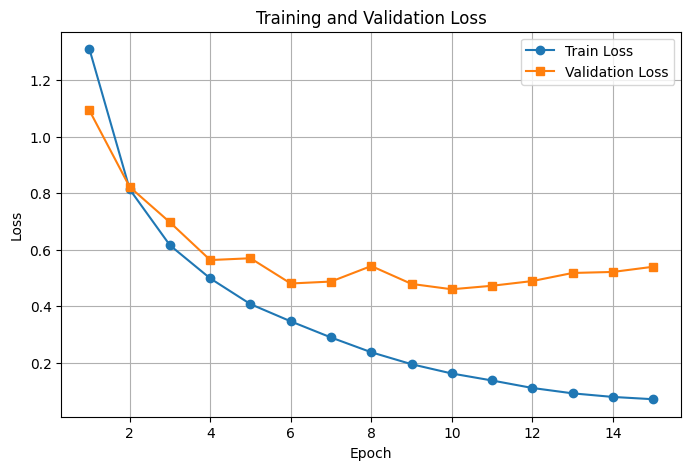

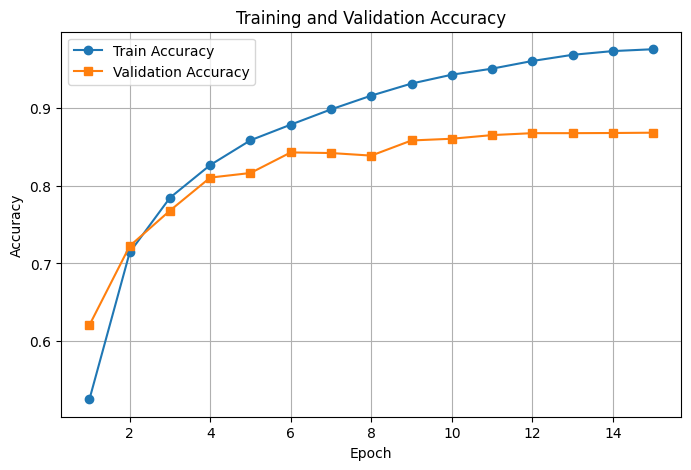

In [ ]:
#plotting
# ------------------------------------------------------------
# Plotting cell:
# show training and validation loss / accuracy
# ------------------------------------------------------------

import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

# ------------------------------------------------------------
# plot training and validation loss
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker='o', label='Train Loss')
plt.plot(epochs, val_losses, marker='s', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# plot training and validation accuracy
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracies, marker='o', label='Train Accuracy')
plt.plot(epochs, val_accuracies, marker='s', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()